# Exp 1: all-fish flickering raster

This is the first experiment-specific notebook for `Exp_1_flickering`. It is the maintained equivalent of cells 5-7 in `oldnotebooks/Exp1_flickers_several_fish.ipynb`: load the selected fish, validate the Exp 1 stimuli, build an all-fish z-score matrix, and save a correlation-sorted raster.

Edit only `USER_SETTINGS` and `REPORT_SETTINGS`. Future Exp 1 per-fish notebooks should reuse the same loading and report pattern.

In [1]:
# Cell 01 - Setup
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.analysis_tools as at
import src.multifish_analysis as mfa
import src.plotting as plott
plott = importlib.reload(plott)
import src.reusable_several_fish as rsf
rsf = importlib.reload(rsf)


In [2]:
# Cell 02 - Exp 1 settings
# Change this cell for a different Exp 1 cohort or plotting choice.
USER_SETTINGS = {
    'experiment_name': 'Exp_1_flickering',
    'data_base': Path(r'D:\Alejandro\Data'),
    'fish_ids': [
        'L433_f02',
        'L433_f04',
        'L453_f09',
        'L453_f11',
        #'L453_f05',
        'L453_f08',
    ],
    'selected_blocks': ['B1', 'B2'],
    'verbose_loading': False,
    'timing': {'fps_2p': 2.0, 't_pre_s': 5.0, 't_post_s': 32.0},
    # Legacy Exp 1 order: FLB, FL1, FL2, FL3, FRB, FR1, FR2, FR3.
    'stim_order': [4, 1, 2, 3, 8, 5, 6, 7],
    'combine_mode': 'mean',#, 'concat',
    'trace_type': 'zscore',
    # Use 'corravg' or 'left_right_index'.
    'raster_sort_mode': 'left_right_index',
    'left_control': 4,   # FLB
    'right_control': 8,  # FRB
}


# Set save_report=True only after reviewing a run.
REPORT_SETTINGS = {
    'save_report': False,
    'run_label': 'all_fish_zscore_concat_corravg',
    'report_format': 'html',
    'export_notebook': True,
    'fallback_to_html': True,
    'comments': 'none for nwow',
}


In [3]:
# Load and validate the selected fish silently; an error is shown only if data or stimuli are missing.
raster_inputs = rsf.load_and_preflight_fish_raster_inputs(USER_SETTINGS)
globals().update(raster_inputs)
stimuli_colors, stimuli_linestyles = plott.build_stimulus_style_maps(stimuli_names=stimuli_names)
print('Detected stimulus map:', stimuli_id_map)


Detected stimulus map: {'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}


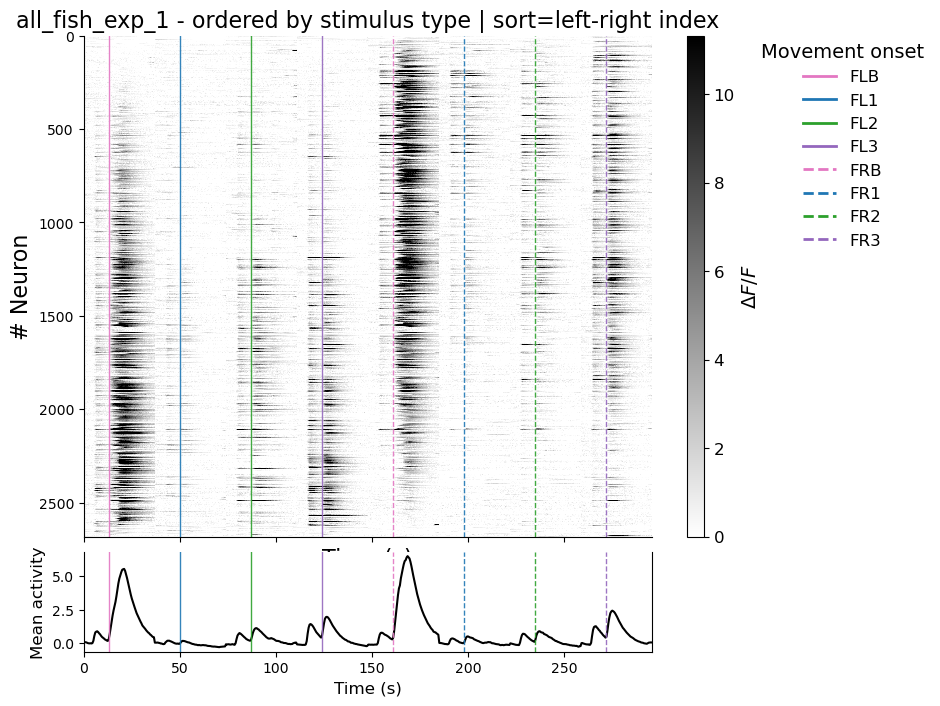

In [4]:
# Build, order, and display the all-fish raster using the settings above.
FIGSIZE = (8, 8)
raster_result = rsf.build_all_fish_raster_figure(
    all_fish_data, fish_ids, stim_order, reference_fish, timing, settings,
    stimuli_colors, stimuli_linestyles, figsize=FIGSIZE,
)
flat_matrix_all_fish = raster_result['flat_matrix_all_fish']
plt.show()


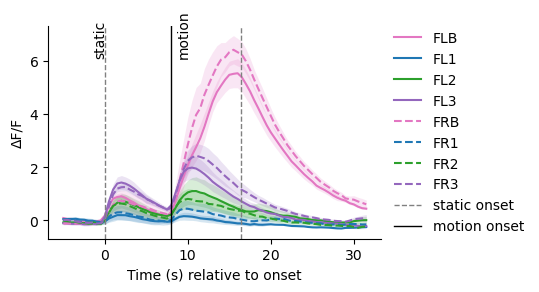

In [5]:
# Cell 05 - Plot mean z-score traces for all selected Exp 1 stimuli.
FIGSIZE = (5.5, 3)
mean_trace_result = rsf.build_plot_all_fish_mean_zscore_traces(
    all_fish_data, fish_ids, stim_order, reference_fish, timing,
    stimuli_colors, stimuli_linestyles, figsize=FIGSIZE,
)


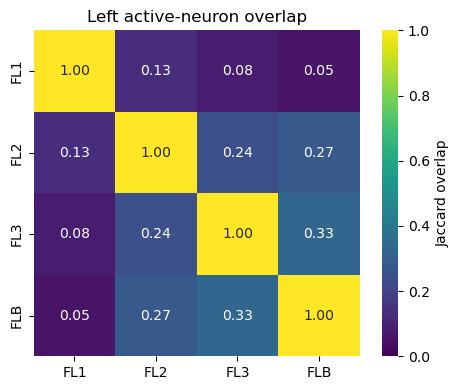

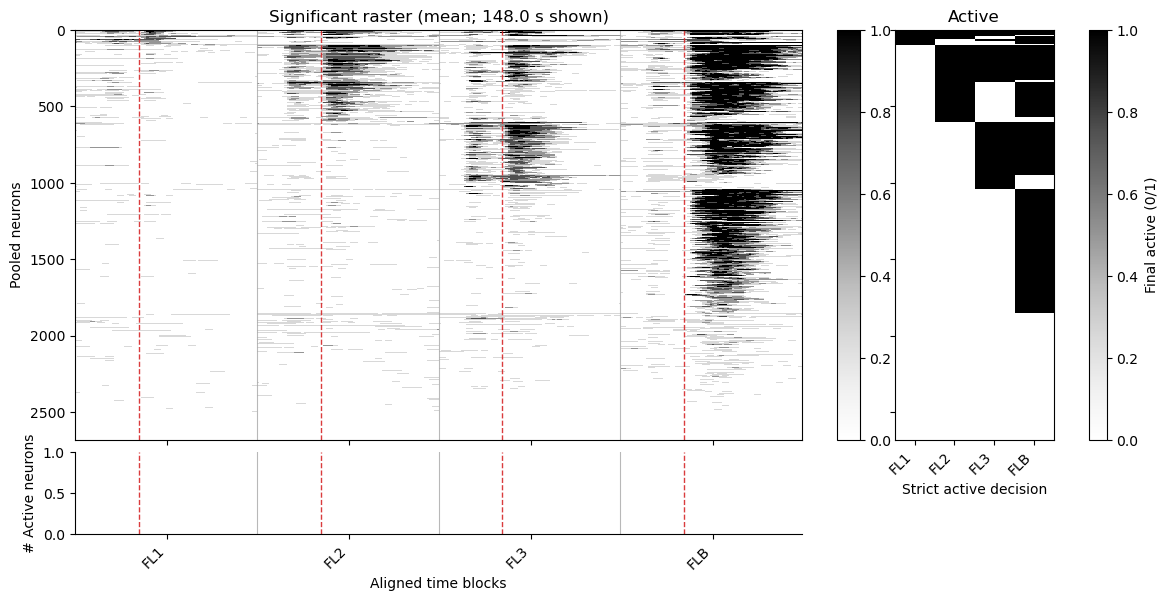

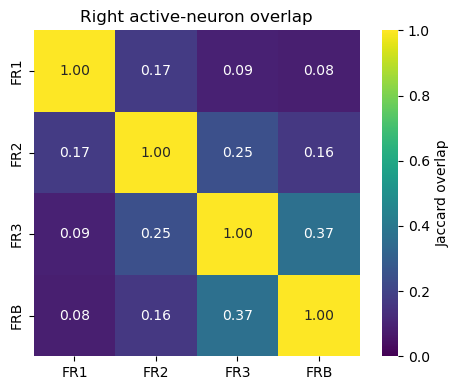

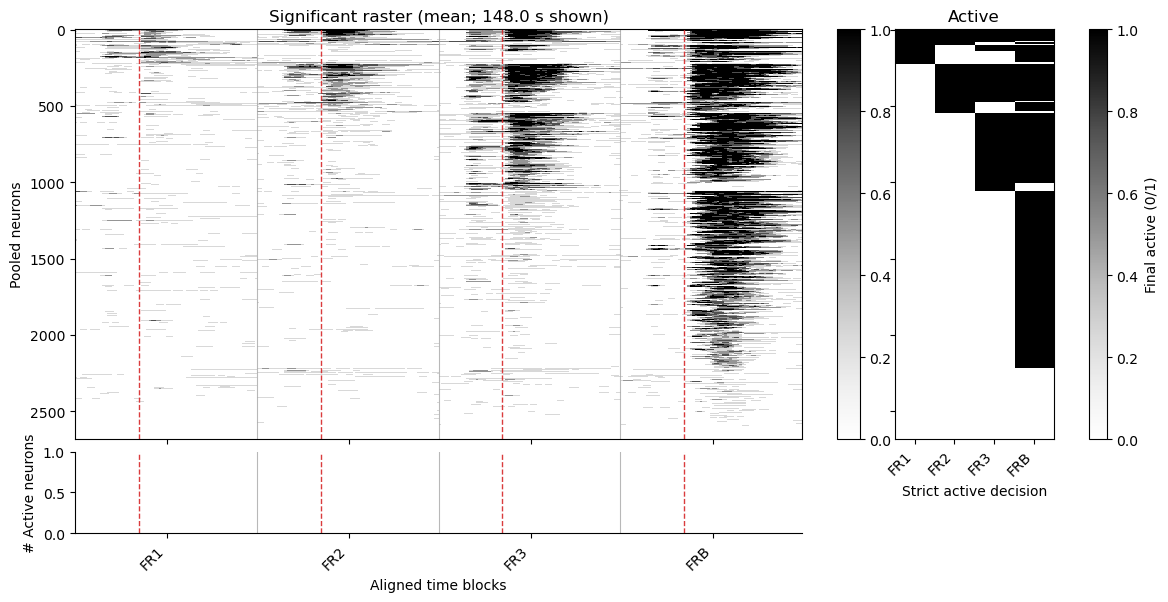

In [6]:
# Cell 06 - Separate left/right active-neuron overlap and significant-raster plots.
OVERLAP_FIGSIZE = (5, 4)
RASTER_FIGSIZE = (12, 7)
OVERLAP_STIMULI = {'left': [1, 2, 3,4], 'right': [5, 6, 7,8]}  # Edit these lists.
overlap_results = rsf.plot_left_right_active_overlap_diagnostics(
    all_fish_data, fish_ids, reference_fish, timing, OVERLAP_STIMULI,
    show_overlap=True, show_significant_raster=True, overlap_figsize=OVERLAP_FIGSIZE,
    raster_figsize=RASTER_FIGSIZE,
)


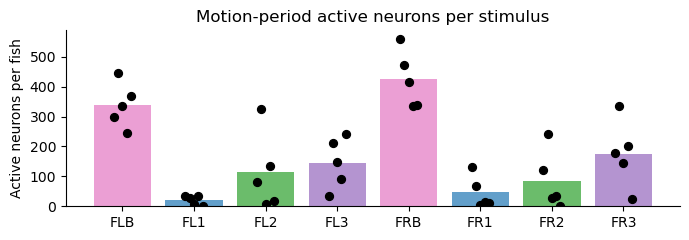

In [7]:
# Cell 07 - Motion-period active neurons per stimulus.
FIGSIZE = (7, 2.5)
motion_active_result = rsf.plot_motion_active_neuron_counts(
    all_fish_data, fish_ids, reference_fish, timing,
    stim_order, stimuli_colors,
    figsize=FIGSIZE,
)
active_neuron_counts = motion_active_result['counts']


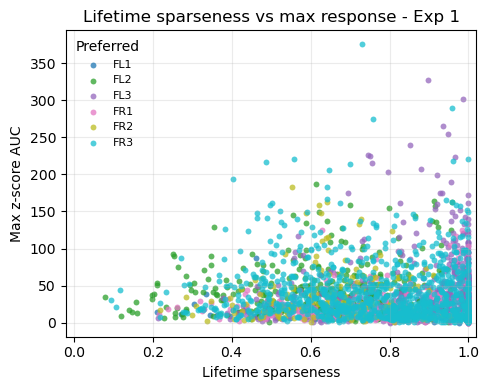

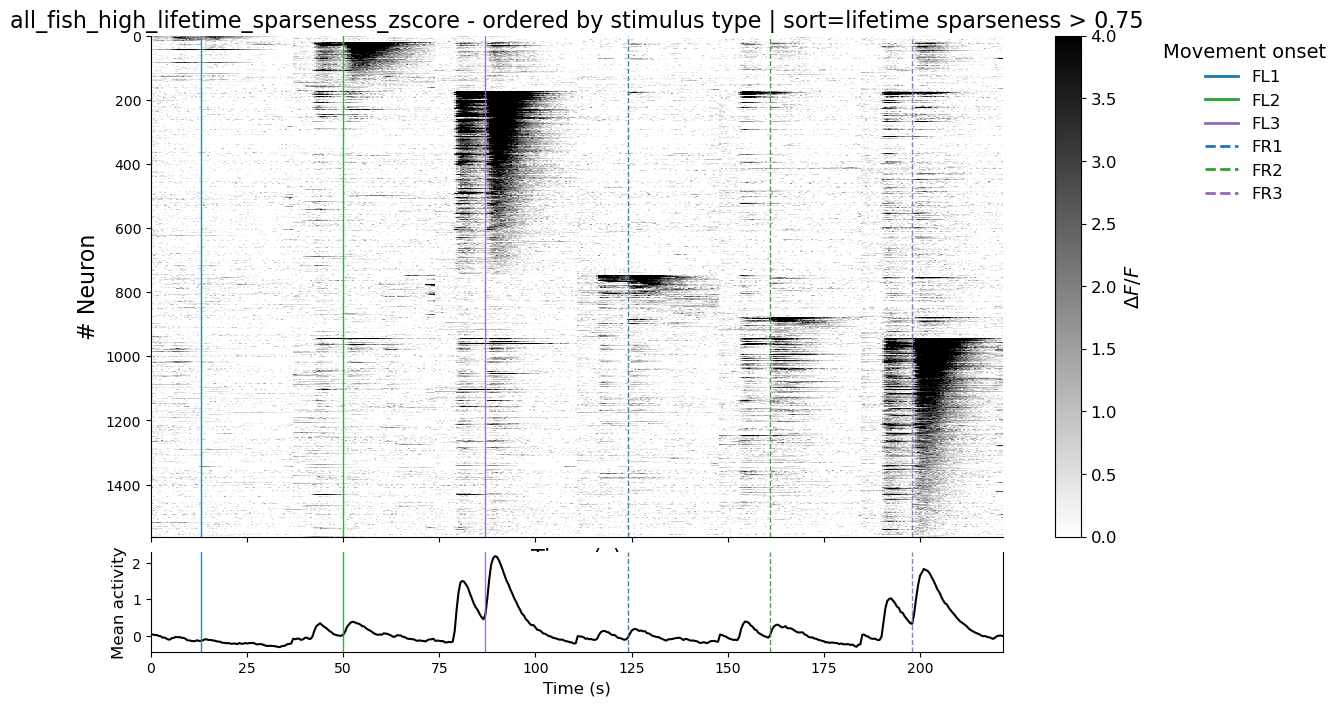

In [13]:
# Cell 08 - Lifetime-sparseness plot and high-sparseness z-score raster only.
SPARSENESS_FIGSIZE = (5, 4)
SPARSENESS_DISTRIBUTION_FIGSIZE = (5, 3)
RASTER_FIGSIZE = (12, 8)
SPARSENESS_STIMULI = [ 1, 2, 3, 5, 6, 7]  # Edit the stimuli to include.
HIGH_LIFETIME_SPARSENESS = 0.75
HIGH_SPARSENESS_COMBINE_MODE = 'mean'#'concat'  # 'concat' or 'mean'.
sparseness_result = rsf.plot_lifetime_sparseness_analysis(
    all_fish_data, fish_ids, reference_fish, timing, SPARSENESS_STIMULI,
    HIGH_LIFETIME_SPARSENESS, stimuli_colors, stimuli_linestyles,
    combine_mode=HIGH_SPARSENESS_COMBINE_MODE, sparseness_figsize=SPARSENESS_FIGSIZE,
    raster_figsize=RASTER_FIGSIZE,
)

# Distribution of lifetime sparseness across all pooled neurons.
lifetime_sparseness = sparseness_result['summary_table']['lifetime_sparseness'].to_numpy(dtype=float)
lifetime_sparseness = lifetime_sparseness[np.isfinite(lifetime_sparseness)]
fig_sparseness_distribution, ax_sparseness_distribution = plt.subplots(
    figsize=SPARSENESS_DISTRIBUTION_FIGSIZE
)
ax_sparseness_distribution.hist(
    lifetime_sparseness, bins=np.linspace(0, 1, 21),
    weights=np.full(lifetime_sparseness.size, 1 / max(lifetime_sparseness.size, 1)),
    color='0.35', edgecolor='white',
)
ax_sparseness_distribution.axvline(
    HIGH_LIFETIME_SPARSENESS, color='crimson', linestyle='--',
    label=f'high-sparseness threshold ({HIGH_LIFETIME_SPARSENESS:g})',
)
ax_sparseness_distribution.set(
    xlim=(0, 1), xlabel='Lifetime sparseness', ylabel='Proportion of neurons',
    title='Lifetime-sparseness distribution',
)
ax_sparseness_distribution.legend(frameon=False)
fig_sparseness_distribution.tight_layout()
plt.show()


In [9]:
# Cell 09 - Optional reviewed-run report
# Save this notebook before enabling REPORT_SETTINGS['save_report'] so the HTML includes current outputs.
notebook_path = repo_root / 'scripts' / 'calcium_analysis' / 'Exp_1_flickering' / '01_all_fish_raster.ipynb'
report_summary = pd.DataFrame([
    {
        'fish_id': fish_id,
        'kept_neurons': len(fish_data['kept_neuron_indices']),
        'detected_stimuli': len(fish_data['stimuli_ids']),
    }
    for fish_id, fish_data in all_fish_data.items()
])
report_result = rsf.save_analysis_report_run(
    settings=settings,
    report_settings=REPORT_SETTINGS,
    analysis_path=analysis_path,
    tables={'run_summary': report_summary},
    notebook_path=notebook_path,
    report_name='01_all_fish_raster_report',
    extra_metadata={
        'stim_order': stim_order,
        'combine_mode': settings['combine_mode'],
        'trace_type': settings['trace_type'],
        'raster_sort_mode': settings['raster_sort_mode'],
        'all_fish_matrix_shape': flat_matrix_all_fish.shape,
    },
)
report_result


Report saving is off. Set REPORT_SETTINGS['save_report'] = True to save this run.
